# Notebook 3 — Science with Publication Bias
**Modeling Social Behavior** | Smaldino

--- 

This is the direct extension of Notebook 1 (Bayesian Updating).  
We take the exact same belief-update machinery, but now introduce a **publication filter**:  
negative results are suppressed with probability `pub_bias`.  
The scientific record becomes *asymmetric*, and we watch how this corrupts collective beliefs.

**Reference:** Based on Nissen et al. (2016) *eLife* — "Publication bias and the canonization of false facts."

---

## 🧠 Conceptual Overview

### What is publication bias?

**Publication bias** is the tendency for scientific journals (and scientists themselves) to publish  
positive results more readily than negative ones.

Reasons this happens:
- Journals prefer "significant" findings — they're more interesting
- Researchers file-drawer null results — why bother writing up a failure?
- Funding and career incentives reward discoveries, not null findings
- Reviewers are more skeptical of null results

### The Bayesian consequence

Recall from Notebook 1: negative results *lower* our belief in H when H is false  
(they're true negatives, good evidence against H). **Suppressing them means we never get that corrective signal.**

With publication bias:
- Positive results (including false positives) → always published → always update beliefs upward
- Negative results → suppressed with probability `pub_bias` → beliefs never update downward

For a **false hypothesis**, this is catastrophic: the only information that could correct beliefs  
gets systematically hidden. False facts can become "canonized" — locked in at near-certainty —  
even though the hypothesis is wrong.

---

### The canonization threshold

This model adds a new concept: **canonization**.  
When `P(H)` crosses a threshold (say 0.999), the hypothesis is declared scientifically established.  
When it falls below `1 - threshold` (say 0.001), it's declared false.

The question the simulation answers: **What fraction of the time does a FALSE hypothesis  
get canonized as true?** — and how does `pub_bias` change that fraction?

---

### The key experiment (from Nissen et al.)

Nissen et al. ran thousands of simulations systematically varying:
- `pub_bias` (0 to 1, where 1 = full bias: all negatives suppressed)
- `false_positive_rate` α  
- `power` β  
- `canonization_threshold`

Their headline finding: **even moderate publication bias dramatically increases the rate  
at which false hypotheses get canonized as true.**

This notebook reproduces their core result.


## Setup — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from tqdm.auto import tqdm    # progress bar for the parameter sweep

np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Parameters

### Variable types
- **Global variables:** `initial_prior`, `false_positive_rate`, `power`,  
  `true_hypothesis`, `pub_bias`, `canonization_threshold`, `max_steps`  
  These mirror the NetLogo sliders in `science_pub-bias.nlogo`.

- **Global output variable:** `canonized_true` — the final verdict (1 = canonized TRUE, 0 = canonized FALSE)

No agents. This is a single-trajectory simulation with a stopping rule.


In [2]:
# ── GLOBAL VARIABLES ──────────────────────────────────────────────────────
initial_prior           = 0.5    # Starting belief P(H)

false_positive_rate     = 0.25   # α — Type I error rate
                                  # Note: the default in this model is HIGHER than Notebook 1
                                  # This represents common underpowered / exploratory research

power                   = 0.8    # β — sensitivity of the test

true_hypothesis         = False  # ← KEY: set to FALSE so we're asking whether a WRONG
                                  # hypothesis gets canonized as TRUE

pub_bias                = 1.0    # Publication bias: 
                                  # 0 = no bias (all results published)
                                  # 1 = full bias (all NEGATIVE results suppressed)
                                  # Intermediate values: negatives published with prob (1 - pub_bias)

canonization_threshold  = 0.999  # P(H) must exceed this to be "canonized TRUE"
                                  # or fall below (1 - threshold) to be "canonized FALSE"

max_steps               = 1000   # Maximum experiments before we stop (if no canonization)

print("Parameters set.")
print(f"  pub_bias = {pub_bias}  (1 = all negatives suppressed)")
print(f"  H is actually: {'TRUE' if true_hypothesis else 'FALSE'}")
print(f"  Canonization threshold: {canonization_threshold}")


Parameters set.
  pub_bias = 1.0  (1 = all negatives suppressed)
  H is actually: FALSE
  Canonization threshold: 0.999


## Core Logic — Update with Publication Bias

This extends the `bayesian_update` function from Notebook 1.  
The key change: **negative results are only published (and thus only update beliefs)  
with probability `(1 - pub_bias)`**.

A positive result always gets published and always updates beliefs upward.


In [3]:
def bayesian_update(prob_true, result_positive, power, false_positive_rate):
    """
    Standard Bayesian update (identical to Notebook 1).
    
    LOCAL variable: result_positive (bool), all others passed in.
    Returns the updated probability (float).
    """
    if result_positive:
        numerator   = power * prob_true
        denominator = (power * prob_true) + (false_positive_rate * (1 - prob_true))
    else:
        numerator   = (1 - power) * prob_true
        denominator = ((1 - power) * prob_true) + ((1 - false_positive_rate) * (1 - prob_true))
    
    if denominator == 0:
        return prob_true
    return numerator / denominator


def run_with_pub_bias(initial_prior, power, false_positive_rate,
                      true_hypothesis, pub_bias, canonization_threshold, max_steps):
    """
    Run the publication-bias simulation.
    
    Differences from Notebook 1:
      - Negative results are only processed/published with probability (1 - pub_bias).
        When pub_bias = 1, negative results are ALWAYS suppressed.
      - Simulation stops when belief crosses canonization_threshold.
    
    Parameters  (all GLOBAL values)
    ----------
    pub_bias              : float in [0,1] — probability that a NEGATIVE result is SUPPRESSED
    canonization_threshold: float in [0,1] — threshold for declaring a hypothesis established
    
    Returns
    -------
    history        : list of floats — P(H) trajectory
    canonized_true : int or None   — 1 if canonized as true, 0 if false, None if timeout
    """
    
    prob_true = initial_prior   # LOCAL: current belief (starts at prior)
    history   = [prob_true]
    
    for step in range(max_steps):
        
        # ── Check for canonization BEFORE running the experiment ──────────
        # (mirrors the NetLogo go procedure: check at start of each tick)
        if prob_true >= canonization_threshold:
            return history, 1   # canonized as TRUE
        if prob_true <= (1 - canonization_threshold):
            return history, 0   # canonized as FALSE
        
        # ── Determine the experimental outcome ────────────────────────────
        if true_hypothesis:
            result_positive = (np.random.random() < power)         # true positive
        else:
            result_positive = (np.random.random() < false_positive_rate)  # false positive
        
        # ── Publication filter ────────────────────────────────────────────
        if result_positive:
            # Positive results are ALWAYS published — update beliefs
            prob_true = bayesian_update(prob_true, True, power, false_positive_rate)
        else:
            # Negative results are SUPPRESSED with probability pub_bias
            # They are published (and thus update beliefs) with prob (1 - pub_bias)
            if np.random.random() < (1 - pub_bias):
                # This negative result makes it through the filter → update
                prob_true = bayesian_update(prob_true, False, power, false_positive_rate)
            # If suppressed: no update, belief stays the same (the result is invisible)
        
        history.append(prob_true)
    
    return history, None   # timeout: no canonization within max_steps


# ── Quick demo run ────────────────────────────────────────────────────────
history, canonized_true = run_with_pub_bias(
    initial_prior, power, false_positive_rate,
    true_hypothesis, pub_bias, canonization_threshold, max_steps
)
result_str = {1: "CANONIZED TRUE ❌ (wrong!)", 0: "Canonized FALSE ✓", None: "No decision"}[canonized_true]
print(f"Single run result: {result_str}")
print(f"Steps taken: {len(history)}")
print(f"Final belief: {history[-1]:.4f}")


Single run result: CANONIZED TRUE ❌ (wrong!)
Steps taken: 12
Final belief: 0.9991


## Visualization 1 — Single Run Trajectory

Compare what happens with and without publication bias on a FALSE hypothesis.


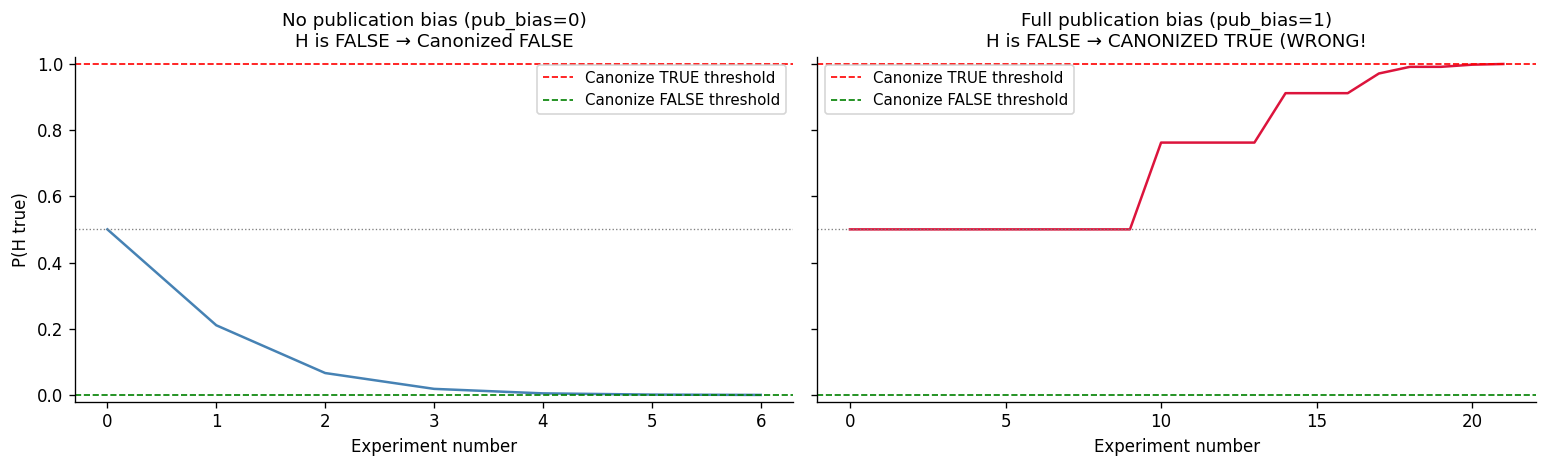

With full pub bias: only positive results accumulate → false hypothesis drifts toward 'TRUE'


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
np.random.seed(99)  # fix seed for reproducible comparison

# ── Left: no publication bias ─────────────────────────────────────────────
ax = axes[0]
h_none, c_none = run_with_pub_bias(0.5, 0.8, 0.25, False, 0.0, 0.999, 1000)
ax.plot(h_none, color="steelblue", linewidth=1.5)
ax.axhline(0.999, color="red",   linestyle="--", linewidth=1, label="Canonize TRUE threshold")
ax.axhline(0.001, color="green", linestyle="--", linewidth=1, label="Canonize FALSE threshold")
ax.axhline(0.5,   color="gray",  linestyle=":",  linewidth=0.8)
result_str = {1:"CANONIZED TRUE", 0:"Canonized FALSE", None:"Timeout"}[c_none]
ax.set_title(f"No publication bias (pub_bias=0)\nH is FALSE → {result_str}", fontsize=11)
ax.set_xlabel("Experiment number"); ax.set_ylabel("P(H true)"); ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=9)

# ── Right: full publication bias ──────────────────────────────────────────
ax = axes[1]
np.random.seed(99)  # same seed for fair comparison
h_full, c_full = run_with_pub_bias(0.5, 0.8, 0.25, False, 1.0, 0.999, 1000)
ax.plot(h_full, color="crimson", linewidth=1.5)
ax.axhline(0.999, color="red",   linestyle="--", linewidth=1, label="Canonize TRUE threshold")
ax.axhline(0.001, color="green", linestyle="--", linewidth=1, label="Canonize FALSE threshold")
ax.axhline(0.5,   color="gray",  linestyle=":",  linewidth=0.8)
result_str = {1:"CANONIZED TRUE (WRONG!", 0:"Canonized FALSE ✓", None:"Timeout"}[c_full]
ax.set_title(f"Full publication bias (pub_bias=1)\nH is FALSE → {result_str}", fontsize=11)
ax.set_xlabel("Experiment number")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print("With full pub bias: only positive results accumulate → false hypothesis drifts toward 'TRUE'")

## Visualization 2 — Canonization Rate vs. Publication Bias

This is the main result from Nissen et al. (2016).  
We run 500 simulations at each pub_bias level and count what fraction canonize the FALSE hypothesis as TRUE.


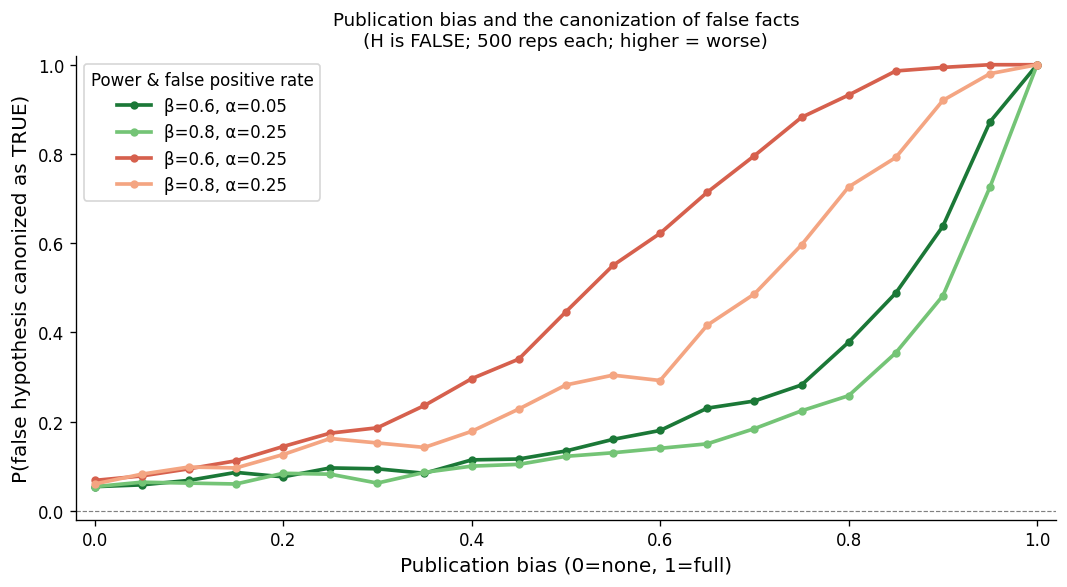

Key result: Even moderate publication bias (e.g., 0.5) substantially raises
the risk that false hypotheses get locked in as canonical scientific facts.
High false positive rates (α=0.25) make the situation dramatically worse.


In [8]:
n_reps      = 500       # repetitions per pub_bias value
pub_bias_vals = np.arange(0.0, 1.01, 0.05)   # sweep from 0 to 1

# ── Parameter combinations to test (mirrors NetLogo batch experiment) ─────
param_sets = [
    {"power": 0.6, "fpr": 0.05,  "label": "β=0.6, α=0.05",  "color": "#1b7837"},
    {"power": 0.8, "fpr": 0.05,  "label": "β=0.8, α=0.25",  "color": "#74c476"},
    {"power": 0.6, "fpr": 0.25,  "label": "β=0.6, α=0.25",  "color": "#d6604d"},
    {"power": 0.8, "fpr": 0.25,  "label": "β=0.8, α=0.25",  "color": "#f4a582"},
]

fig, ax = plt.subplots(figsize=(9, 5))

for params in param_sets:
    canon_rates = []
    
    for pb in pub_bias_vals:
        # Count how many out of n_reps canonize the FALSE hypothesis as TRUE
        canonized_true_count = 0
        
        for _ in range(n_reps):
            _, result = run_with_pub_bias(
                initial_prior=0.5,
                power=params["power"],
                false_positive_rate=params["fpr"],
                true_hypothesis=False,       # ← always testing a FALSE hypothesis
                pub_bias=pb,
                canonization_threshold=0.9,  # slightly lower for speed
                max_steps=1000
            )
            if result == 1:                  # canonized as TRUE (wrong!)
                canonized_true_count += 1
        
        canon_rates.append(canonized_true_count / n_reps)
    
    ax.plot(pub_bias_vals, canon_rates, color=params["color"],
            linewidth=2.2, marker="o", markersize=4, label=params["label"])

ax.set_xlabel("Publication bias (0=none, 1=full)", fontsize=12)
ax.set_ylabel("P(false hypothesis canonized as TRUE)", fontsize=12)
ax.set_title("Publication bias and the canonization of false facts\n"
             "(H is FALSE; 500 reps each; higher = worse)", fontsize=11)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.axhline(0.0, color="gray", linestyle="--", linewidth=0.7)
ax.legend(title="Power & false positive rate", fontsize=10)

plt.tight_layout()
plt.show()

print("Key result: Even moderate publication bias (e.g., 0.5) substantially raises")
print("the risk that false hypotheses get locked in as canonical scientific facts.")
print("High false positive rates (α=0.25) make the situation dramatically worse.")

## Visualization 3 — Stochastic Spread at Intermediate Pub Bias

At extreme bias values (0 or 1) the outcome is relatively predictable.  
At intermediate values, there's high variance — communities get very different outcomes by chance.


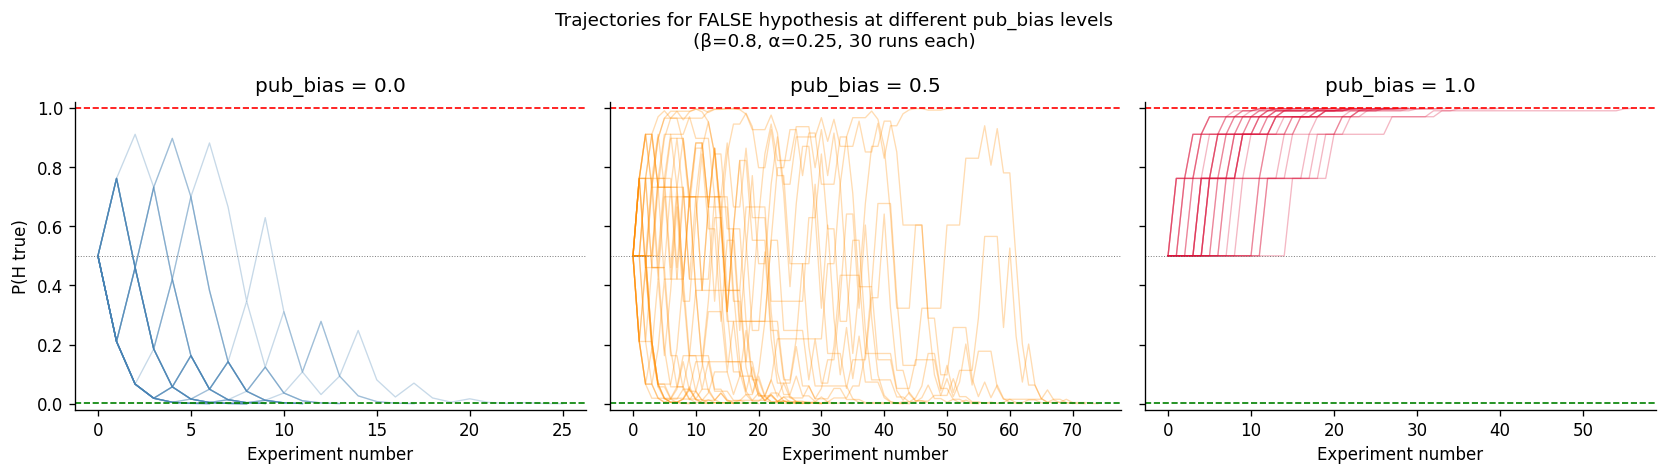

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
n_trajectories = 30

for ax, pb, col in zip(axes, [0.0, 0.5, 1.0], ["steelblue", "darkorange", "crimson"]):
    for _ in range(n_trajectories):
        h, c = run_with_pub_bias(0.5, 0.8, 0.25, False, pb, 0.999, 1000)
        ax.plot(h, color=col, alpha=0.3, linewidth=0.8)
    
    ax.axhline(0.999, color="red",   linestyle="--", linewidth=1)
    ax.axhline(0.001, color="green", linestyle="--", linewidth=1)
    ax.axhline(0.5,   color="gray",  linestyle=":",  linewidth=0.6)
    ax.set_title(f"pub_bias = {pb}", fontsize=12)
    ax.set_xlabel("Experiment number")
    ax.set_ylim(-0.02, 1.02)

axes[0].set_ylabel("P(H true)")
fig.suptitle("Trajectories for FALSE hypothesis at different pub_bias levels\n"
             "(β=0.8, α=0.25, 30 runs each)", fontsize=11)
plt.tight_layout()
plt.show()


## 📝 Key Takeaways

| Concept | What the simulation shows |
|---------|--------------------------|
| **Publication bias = asymmetric evidence** | Only positive signals reach the community; negative signals are silenced |
| **False hypotheses can be canonized** | With high pub_bias and high α, wrong beliefs become "established science" |
| **Power helps, but doesn't save us** | High β slows false canonization but doesn't prevent it under strong bias |
| **High α is especially dangerous** | More false positives + suppressed negatives = faster canonization of falsehoods |
| **The threshold matters** | Stricter canonization thresholds (0.999 vs 0.9) don't help if negatives are always suppressed — just delays the inevitable |

### What this means for replication

When a false hypothesis gets canonized, the scientific community "knows" it's true.  
Replication attempts face headwinds: they must overcome entrenched canonical belief,  
and their negative results will again face publication bias.

This is the mechanism behind decades-long persistence of false effects in psychology,  
nutrition science, cancer pharmacology, and other fields.

### What comes next?

Notebook 4 asks: what happens when *labs themselves evolve*?  
Instead of one community with fixed parameters, we have many labs that  
reproduce based on publication success — and that selection pressure  
systematically evolves labs toward low power and high false positive rates.
